In [1]:
# ===============================
# Cell 1: Import Required Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set(style="whitegrid")

# Display all columns if needed
pd.set_option('display.max_columns', None)

In [2]:
# ===============================
# Cell 2: Load Dataset
# ===============================

# Load dataset (ensure the file is uploaded in Colab)
df = pd.read_csv('/content/titanic.csv')

# Select only the 8 important columns
important_cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone']
df = df[important_cols]

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone
0,0,3,male,22.0,1,0,7.2500,False
1,1,1,female,38.0,1,0,71.2833,False
2,1,3,female,26.0,0,0,7.9250,True
3,1,1,female,35.0,1,0,53.1000,False
4,0,3,male,35.0,0,0,8.0500,True


In [3]:
# ===============================
# Cell 3: Basic Information
# ===============================

print("Shape of Dataset:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

Shape of Dataset: (891, 8)

Data Types:

survived      int64
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
alone          bool
dtype: object

Missing Values:

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
alone         0
dtype: int64


Task 2. Basic Descriptive Analysis

In [4]:
# ===============================
# Cell 4: Descriptive Statistics
# ===============================

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# ===============================
# Cell 5: Categorical Summary
# ===============================

# Summary for categorical variables
df.describe(include='object')

,sex
count,891
unique,2
top,male
freq,577


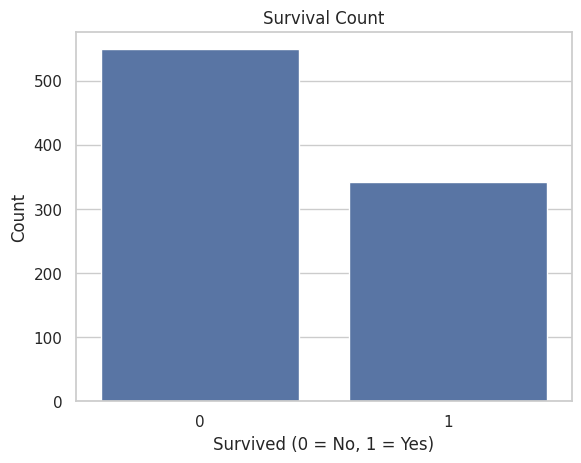

Survival Percentage:
 survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [6]:
# ===============================
# Cell 6: Survival Distribution
# ===============================

plt.figure()
sns.countplot(x='survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Survival percentage
survival_rate = df['survived'].value_counts(normalize=True) * 100
print("Survival Percentage:\n", survival_rate)

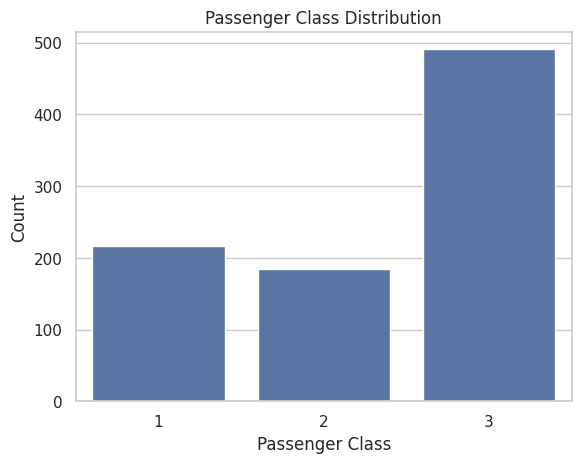


Passenger Class Percentage:

pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64


In [7]:
# ===============================
# Cell 7: Passenger Class Distribution
# ===============================

plt.figure()
sns.countplot(x='pclass', data=df)
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

print("\nPassenger Class Percentage:\n")
print(df['pclass'].value_counts(normalize=True) * 100)

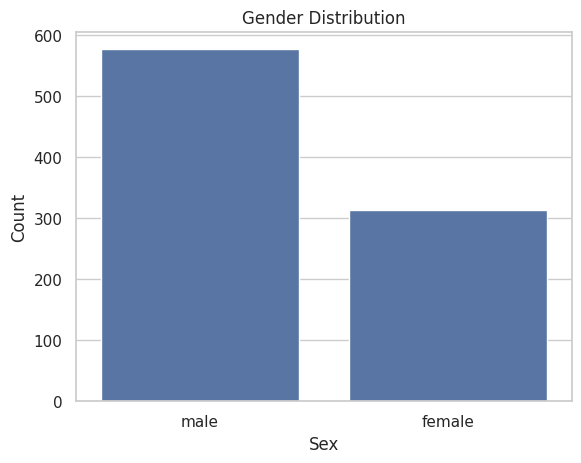


Gender Percentage:

sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64


In [8]:
# ===============================
# Cell 8: Gender Distribution
# ===============================

plt.figure()
sns.countplot(x='sex', data=df)
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

print("\nGender Percentage:\n")
print(df['sex'].value_counts(normalize=True) * 100)

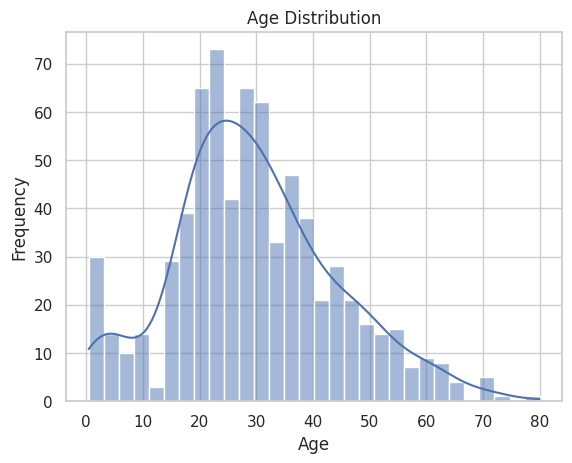

In [9]:
# ===============================
# Cell 9: Age Distribution
# ===============================

plt.figure()
sns.histplot(df['age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

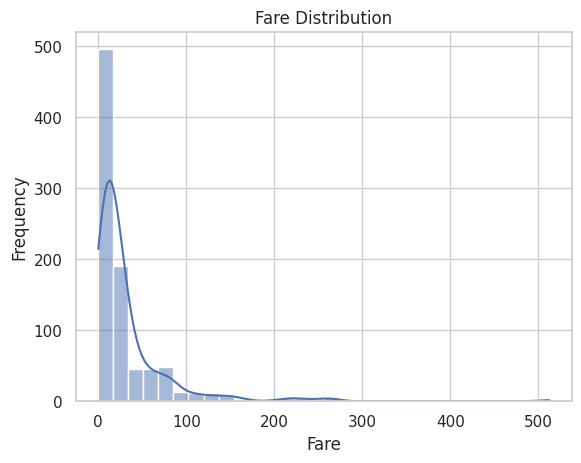

In [10]:
# ===============================
# Cell 10: Fare Distribution
# ===============================

plt.figure()
sns.histplot(df['fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

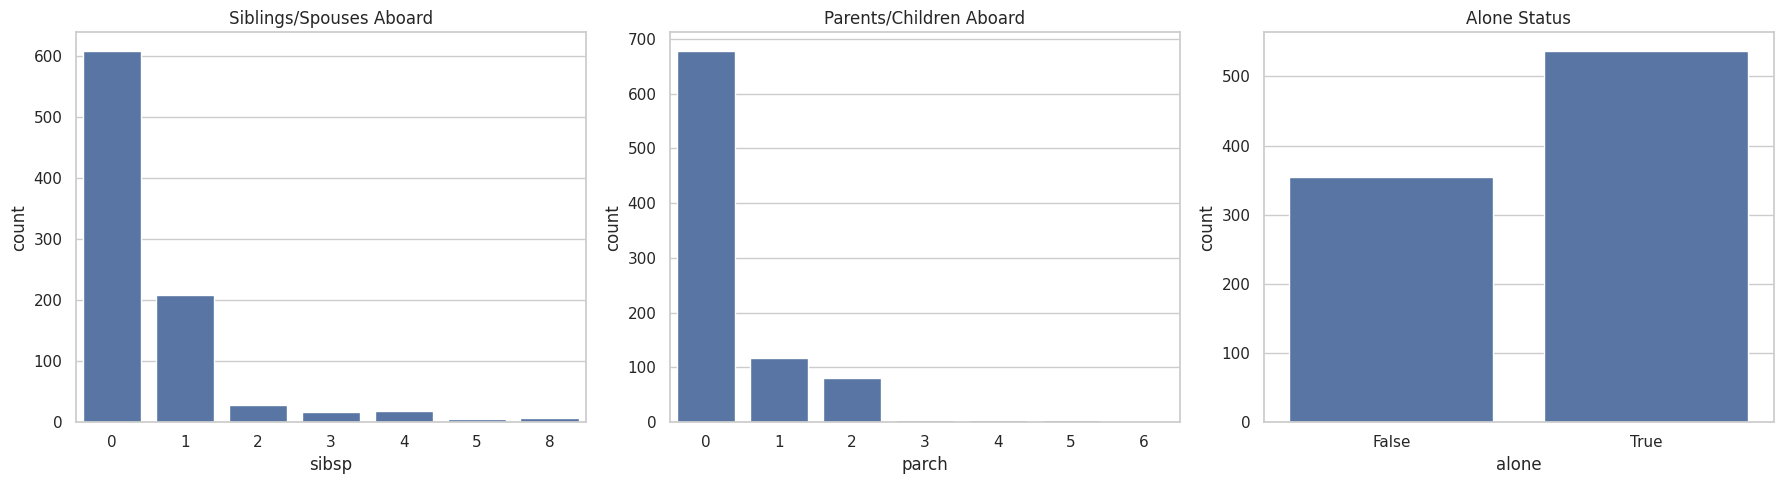

In [11]:
# ===============================
# Cell 11: Family-Related Features
# ===============================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(x='sibsp', data=df, ax=axes[0])
axes[0].set_title('Siblings/Spouses Aboard')

sns.countplot(x='parch', data=df, ax=axes[1])
axes[1].set_title('Parents/Children Aboard')

sns.countplot(x='alone', data=df, ax=axes[2])
axes[2].set_title('Alone Status')

plt.tight_layout()
plt.show()

Task 4. Check for Outlier Values.

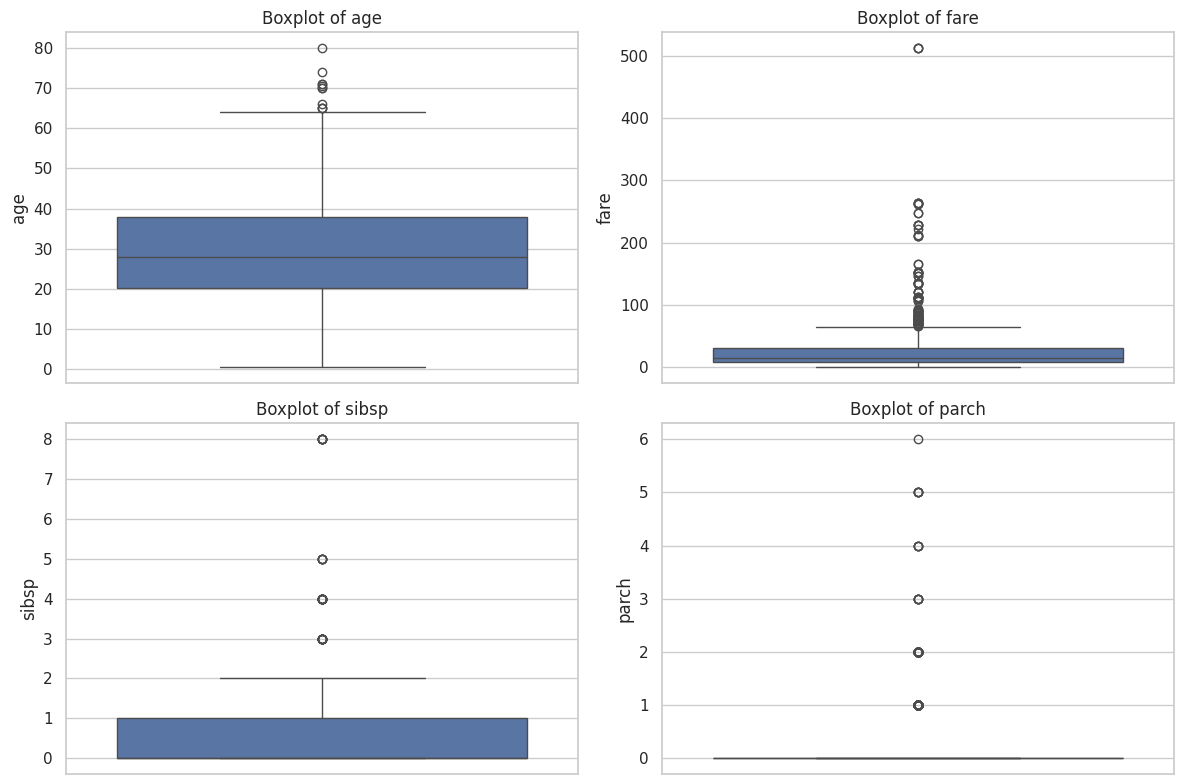

In [12]:
# ===============================
# Cell 1: Boxplots for Outlier Detection
# ===============================

numerical_cols = ['age', 'fare', 'sibsp', 'parch']

plt.figure(figsize=(12,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [14]:
# ===============================
# Cell 2: IQR-Based Outlier Detection
# ===============================

outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

# Convert to DataFrame
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Number_of_Outliers'])

outlier_df

,Number_of_Outliers
age,11
fare,116
sibsp,46
parch,213


In [15]:
# ===============================
# Cell 3: Outlier Percentage
# ===============================

outlier_df['Outlier_Percentage (%)'] = (outlier_df['Number_of_Outliers'] / len(df)) * 100

outlier_df

,Number_of_Outliers,Outlier_Percentage (%)
age,11,1.234568
fare,116,13.019080
sibsp,46,5.162738
parch,213,23.905724


Task 5. Univariate Analysis

In [16]:
# ===============================
# Cell 1: Identify Column Types
# ===============================

numerical_cols = ['age', 'fare', 'sibsp', 'parch']
categorical_cols = ['survived', 'pclass', 'sex', 'alone']

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['age', 'fare', 'sibsp', 'parch']
Categorical Columns: ['survived', 'pclass', 'sex', 'alone']


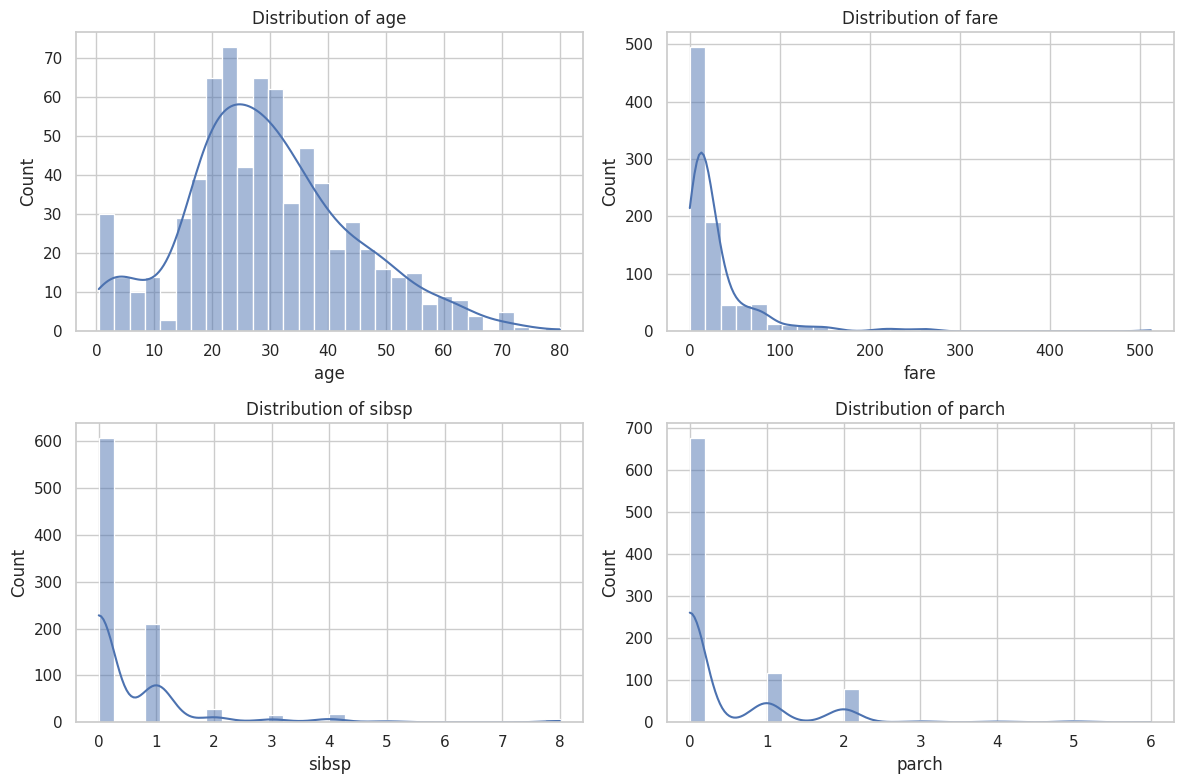

In [17]:
# ===============================
# Cell 2: Distribution of Numerical Variables
# ===============================

plt.figure(figsize=(12,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

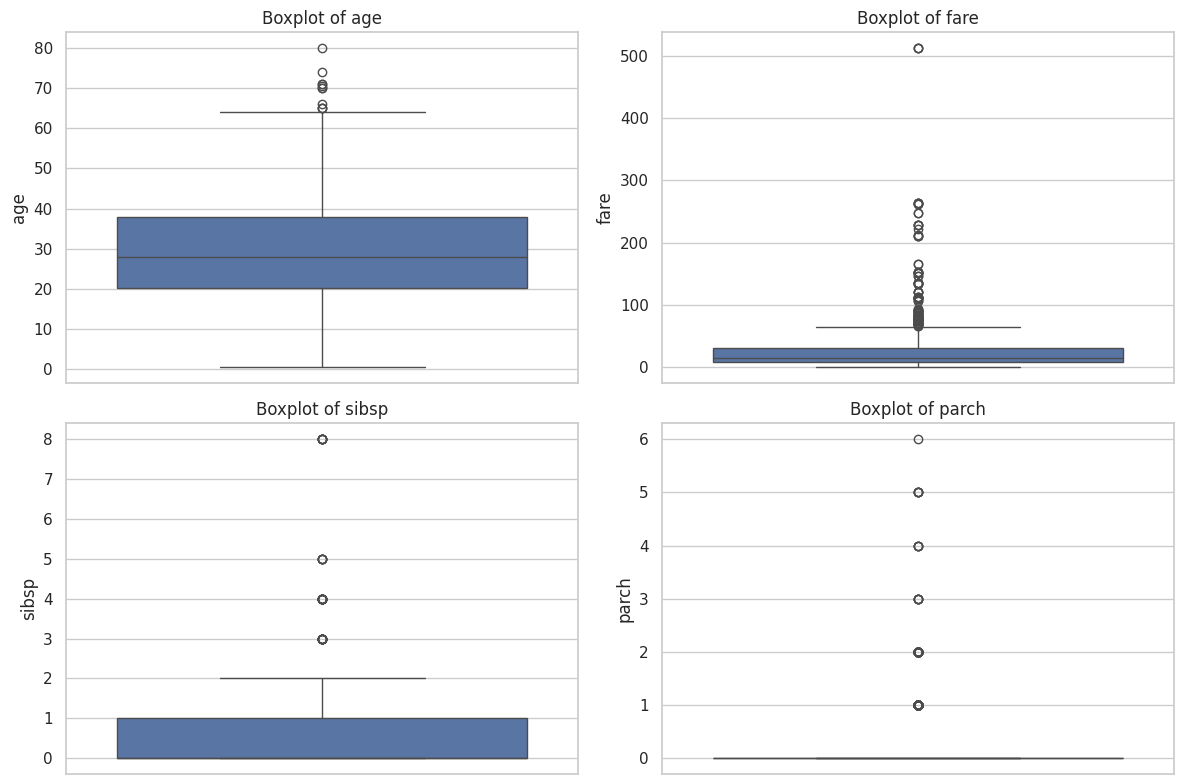

In [18]:
# ===============================
# Cell 3: Boxplots for Numerical Variables
# ===============================

plt.figure(figsize=(12,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [19]:
# ===============================
# Cell 4: Numerical Summary Statistics
# ===============================

df[numerical_cols].describe()

,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


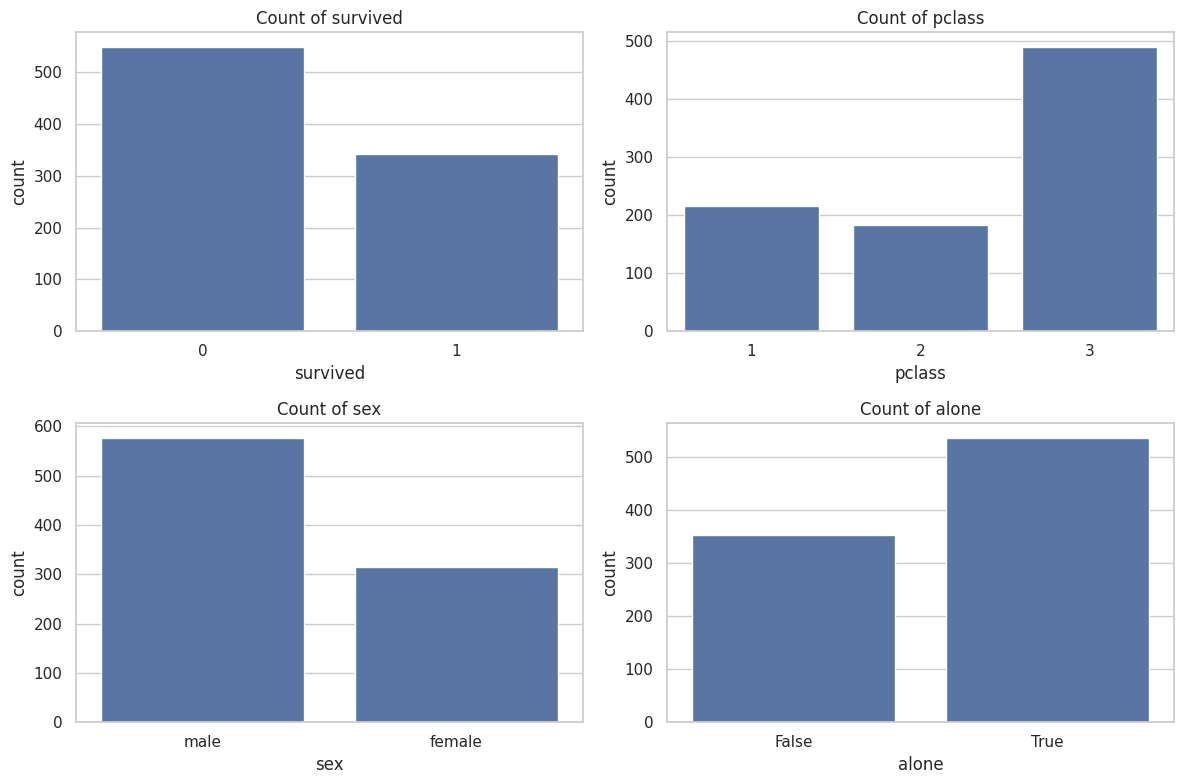

In [20]:
# ===============================
# Cell 5: Categorical Countplots
# ===============================

plt.figure(figsize=(12,8))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col])
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()

In [21]:
# ===============================
# Cell 6: Categorical Percentage Distribution
# ===============================

for col in categorical_cols:
    print(f"\nPercentage Distribution of {col}:")
    print((df[col].value_counts(normalize=True) * 100).round(2))


Percentage Distribution of survived:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Percentage Distribution of pclass:
pclass
3    55.11
1    24.24
2    20.65
Name: proportion, dtype: float64

Percentage Distribution of sex:
sex
male      64.76
female    35.24
Name: proportion, dtype: float64

Percentage Distribution of alone:
alone
True     60.27
False    39.73
Name: proportion, dtype: float64


Task 6. Bivariate Analysis with survived.

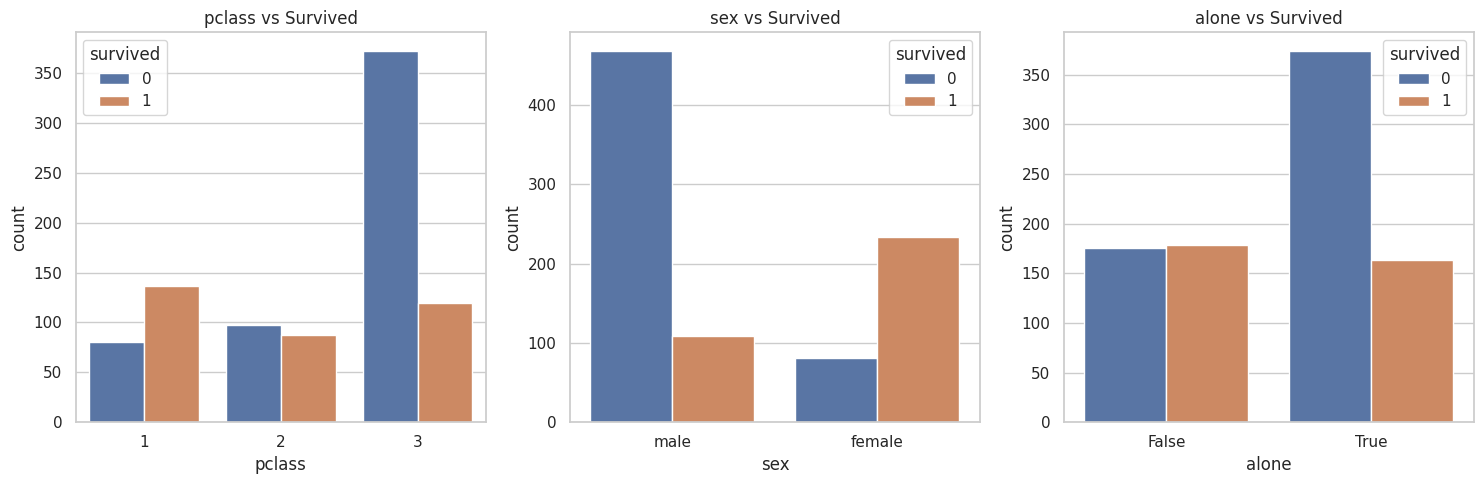

In [22]:
# ===============================
# Cell 1: Categorical vs Survived
# ===============================

categorical_cols = ['pclass', 'sex', 'alone']

plt.figure(figsize=(15,5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=col, hue='survived', data=df)
    plt.title(f'{col} vs Survived')

plt.tight_layout()
plt.show()

In [23]:
# ===============================
# Cell 2: Survival Rate by Category
# ===============================

for col in categorical_cols:
    print(f"\nSurvival Rate by {col}:")
    print(pd.crosstab(df[col], df['survived'], normalize='index') * 100)


Survival Rate by pclass:
survived          0          1
pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253

Survival Rate by sex:
survived          0          1
sex                           
female    25.796178  74.203822
male      81.109185  18.890815

Survival Rate by alone:
survived          0          1
alone                         
False     49.435028  50.564972
True      69.646182  30.353818


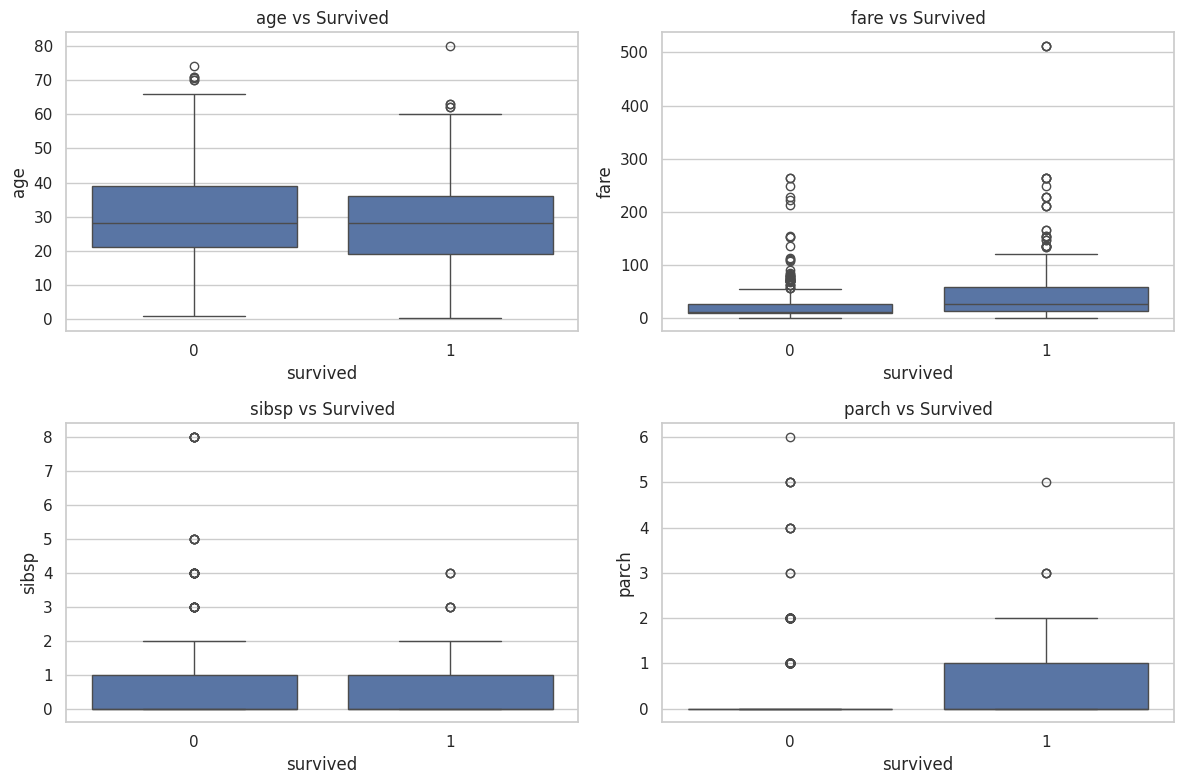

In [24]:
# ===============================
# Cell 3: Numerical vs Survived (Boxplots)
# ===============================

numerical_cols = ['age', 'fare', 'sibsp', 'parch']

plt.figure(figsize=(12,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='survived', y=col, data=df)
    plt.title(f'{col} vs Survived')

plt.tight_layout()
plt.show()

In [25]:
# ===============================
# Cell 4: Mean Comparison by Survival
# ===============================

df.groupby('survived')[numerical_cols].mean()

,age,fare,sibsp,parch
survived,,,,
0,30.626179,22.117887,0.553734,0.329690
1,28.343690,48.395408,0.473684,0.464912
